In [1]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [4]:
from textblob import TextBlob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#import matplotlab
import nltk
import nltk
import re
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
from collections import Counter
sns.set()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Mallika\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Mallika\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Mallika\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [5]:
from nltk.corpus import stopwords

In [6]:
with open('webpage_source.txt', 'r', errors='ignore') as file: 
   data = file.read().replace( '\n', ' ')

In [7]:
from nltk.tokenize import sent_tokenize
tokenized_sent = sent_tokenize(data)
#print(tokenized_sent) 

In [8]:
from nltk.tokenize import word_tokenize
tokenized_word = word_tokenize(data)
#print(tokenized_word) 

In [9]:
from nltk.probability import FreqDist
dist_words = FreqDist(tokenized_word)
print(dist_words)

<FreqDist with 4838 samples and 22336 outcomes>


In [10]:
dist_words.most_common(10)

[('.', 1642),
 ('the', 1134),
 (',', 980),
 ('of', 620),
 ('and', 412),
 ('to', 327),
 ('The', 320),
 ('[', 309),
 (']', 309),
 ('in', 307)]

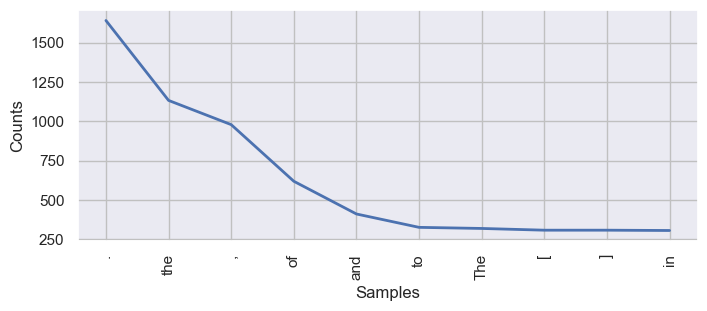

In [11]:
plt.figure(figsize=(8, 3))
dist_words.plot(10,cumulative = False)
plt.show()

In [12]:
filtered_words = [] # creates an empty list
for word in tokenized_word:
      if word not in stopwords.words():
           filtered_words.append(word)

In [324]:
#print(filtered_words)

In [104]:
dist_words_filter = FreqDist(filtered_words)
print (dist_words_filter)

<FreqDist with 4575 samples and 16758 outcomes>


In [105]:
dist_words_filter.most_common(10)

[('.', 1642),
 (',', 980),
 ('The', 320),
 ('[', 309),
 (']', 309),
 ("''", 275),
 ('^', 274),
 ('``', 271),
 ('(', 255),
 (')', 255)]

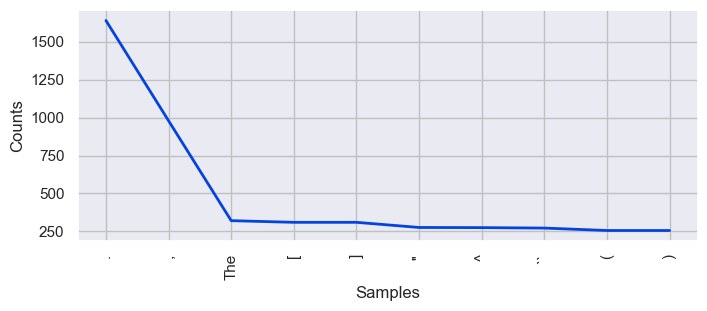

In [106]:
plt.figure(figsize=(8, 3))
dist_words_filter.plot(10,cumulative = False)
plt.show()

In [107]:
sans_punc = re.sub("[^a-zA-Z]",  # Search for all non-letters
                        " ",        # Replace all non-letters with spaces
                        str(filtered_words))

In [108]:
#print(sans_punc)

In [109]:
tokenized_word_2 = word_tokenize(sans_punc)
#print (tokenized_word_2)

In [110]:
dist_words_filter_2 = FreqDist(tokenized_word_2) 

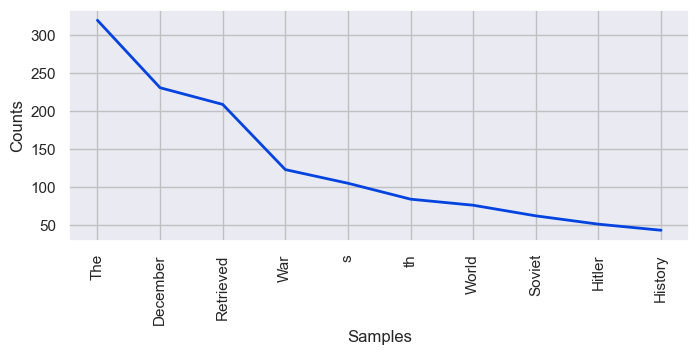

In [111]:
plt.figure(figsize=(8, 3))
dist_words_filter_2.plot(10,cumulative = False)
plt.show()

In [112]:
#OBSERVATION: The results look much better! The reults for "THE" looks better. On the other hand, some letters have made it into the list. This is probably because some punctuation marks were removed earlier on when the stop word list was created.

In [113]:
%%time
text = TextBlob(str(filtered_words))

CPU times: total: 46.9 ms
Wall time: 44.7 ms


In [114]:
tags_list = text.tags
#tags_list

In [117]:
df_text = pd.DataFrame(tags_list)
df_text.columns = [ 'Words', "Word type"]
df_t=df_text.groupby('Word type').count().reset_index()
top10=df_t.nlargest(20, 'Words')

In [164]:
print(top10)

   Word type  Words
13       POS   9247
11       NNP   8035
12       NNS   1011
16       VBD    838
6         JJ    401
10        NN    340
17       VBG    306
1         CD    193
15        RB    135
5         IN    108
8        JJS     56
20       VBZ     52
4         FW     30
14       PRP     21
0         CC     18
18       VBN     18
2         DT     13
3         EX     12
7        JJR     11
21        WP     10


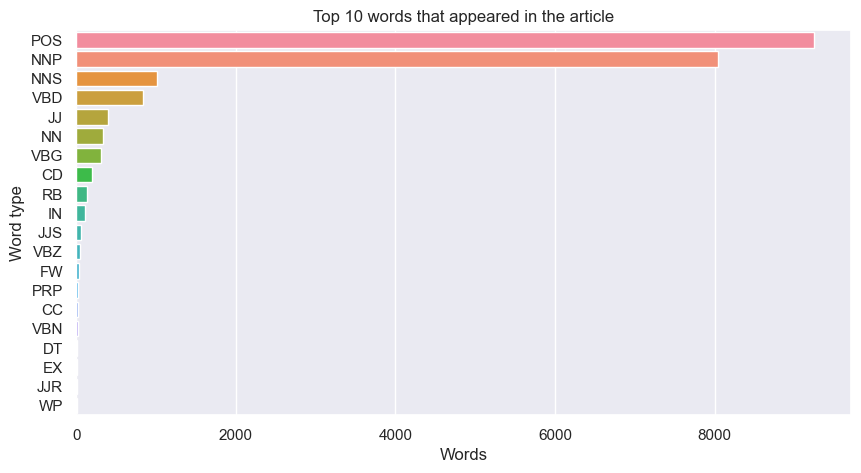

In [127]:
plt.figure(figsize = (10, 5))
with sns.dark_palette("xkcd:blue", 10):
      sns.barplot(x = "Words", y = "Word type",
     saturation = 0.9, data = top10).set_title("Top 10 words that appeared in the article")

In [134]:
#noun
df_noun = df_text[(df_text['Word type'] == "NN") | (df_text['Word type'] == "NNS") | (df_text['Word type'] == "NNS")]
df_noun.columns = ["Word", "Occurrences"]
x = df_noun.groupby('Word').count().reset_index()
y = x.sort_values(by = ['Occurrences'], ascending=False)
top15 = y.nlargest(15, 'Occurrences') 

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
 [Text(0, 0, "'Germans"),
  Text(1, 0, "'Union"),
  Text(2, 0, "'weapons"),
  Text(3, 0, "'Allies"),
  Text(4, 0, 'p'),
  Text(5, 0, "'forces"),
  Text(6, 0, "'Jews"),
  Text(7, 0, "'countries"),
  Text(8, 0, "'nations"),
  Text(9, 0, "'troops"),
  Text(10, 0, "'Nations"),
  Text(11, 0, "'wars"),
  Text(12, 0, "'camps"),
  Text(13, 0, "'days"),
  Text(14, 0, "'News")])

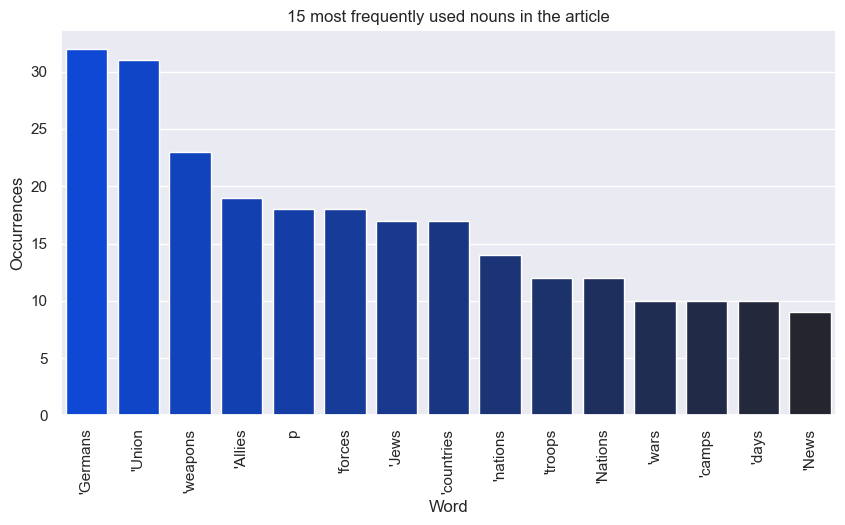

In [135]:
plt.figure(figsize=(10, 5))
sns.set_palette(sns.dark_palette("xkcd:blue", 15, reverse=True))
sns.barplot(
    x="Word",
    y="Occurrences",
    saturation=0.9,
    data=top15
).set_title("15 most frequently used nouns in the article")
plt.xticks(rotation=90)

In [136]:
#Verb
df_verb = df_text[(df_text['Word type'] == "VBZ") | (df_text['Word type'] == "VBN") | (df_text['Word type'] == "VBG")]
df_verb.columns = ["Word", "Occurrences"]
x = df_verb.groupby('Word').count().reset_index()
y = x.sort_values(by = ['Occurrences'], ascending=False)
top15 = y.nlargest(15, 'Occurrences') 

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
 [Text(0, 0, "'States"),
  Text(1, 0, "'including"),
  Text(2, 0, "'leading"),
  Text(3, 0, "'Publishing"),
  Text(4, 0, "'beginning"),
  Text(5, 0, "'During"),
  Text(6, 0, "'systems"),
  Text(7, 0, "'ending"),
  Text(8, 0, "'bombing"),
  Text(9, 0, "'taking"),
  Text(10, 0, "'Following"),
  Text(11, 0, "'turning"),
  Text(12, 0, "'Learning"),
  Text(13, 0, "'attacking"),
  Text(14, 0, "'devastating")])

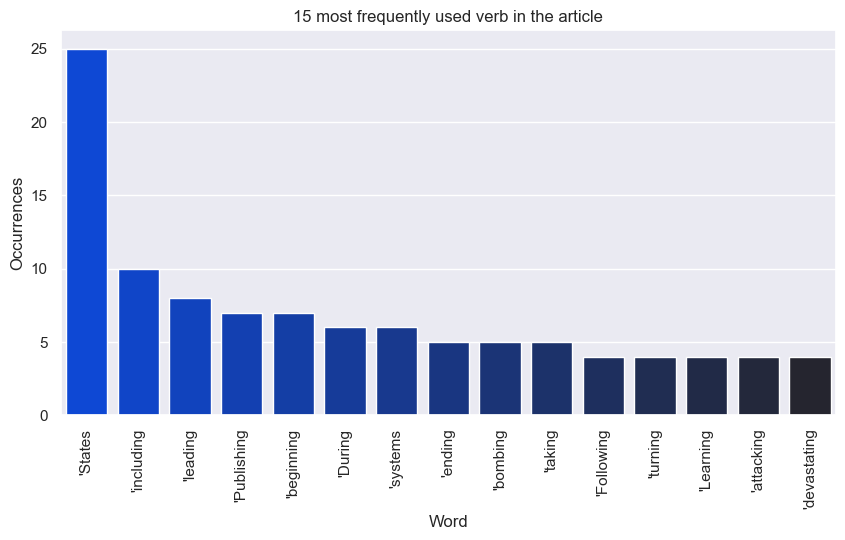

In [137]:
plt.figure(figsize=(10, 5))
sns.set_palette(sns.dark_palette("xkcd:blue", 15, reverse=True))
sns.barplot(
    x="Word",
    y="Occurrences",
    saturation=0.9,
    data=top15
).set_title("15 most frequently used verb in the article")
plt.xticks(rotation=90)

In [138]:
#adjectives
df_adjectives = df_text[(df_text['Word type'] == "JJ") | (df_text['Word type'] == "JJR") | (df_text['Word type'] == "JJS")]
df_adjectives.columns = ["Word", "Occurrences"]
x = df_adjectives.groupby('Word').count().reset_index()
y = x.sort_values(by = ['Occurrences'], ascending=False)
top15 = y.nlargest(15, 'Occurrences') 

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
 [Text(0, 0, "'Japanese"),
  Text(1, 0, "'American"),
  Text(2, 0, "'Atlantic"),
  Text(3, 0, "'Guardian"),
  Text(4, 0, "'West"),
  Text(5, 0, "'0261-3077"),
  Text(6, 0, "'largest"),
  Text(7, 0, "'power"),
  Text(8, 0, "'Chinese"),
  Text(9, 0, "'Interest"),
  Text(10, 0, "'Russian"),
  Text(11, 0, "'0362-4331"),
  Text(12, 0, "'political"),
  Text(13, 0, "'African"),
  Text(14, 0, "'Baltic")])

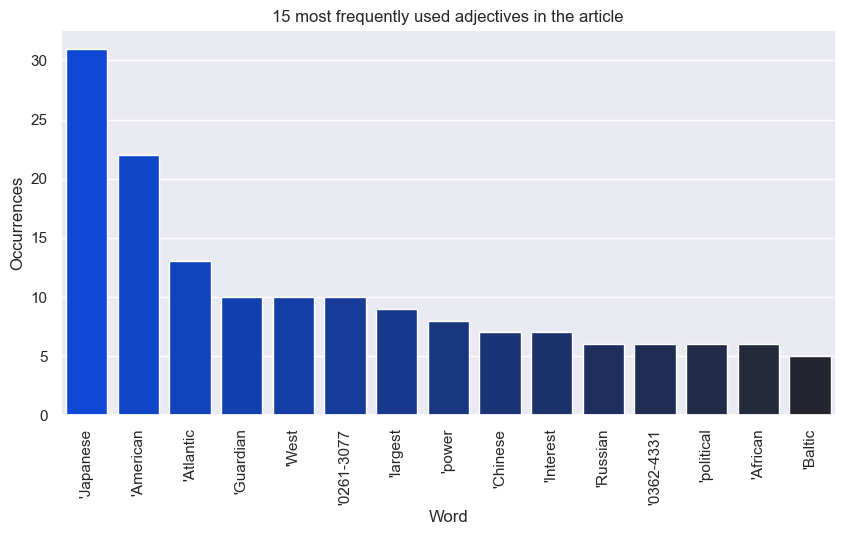

In [139]:
plt.figure(figsize=(10, 5))
sns.set_palette(sns.dark_palette("xkcd:blue", 15, reverse=True))
sns.barplot(
    x="Word",
    y="Occurrences",
    saturation=0.9,
    data=top15
).set_title("15 most frequently used adjectives in the article")
plt.xticks(rotation=90)

In [140]:
#observation: The 'Japanese' adjective, 'States' & 'including' as verb and 'germans' as noun stands out in the article whereas other nouns, verbs and adjectives have made into the list.

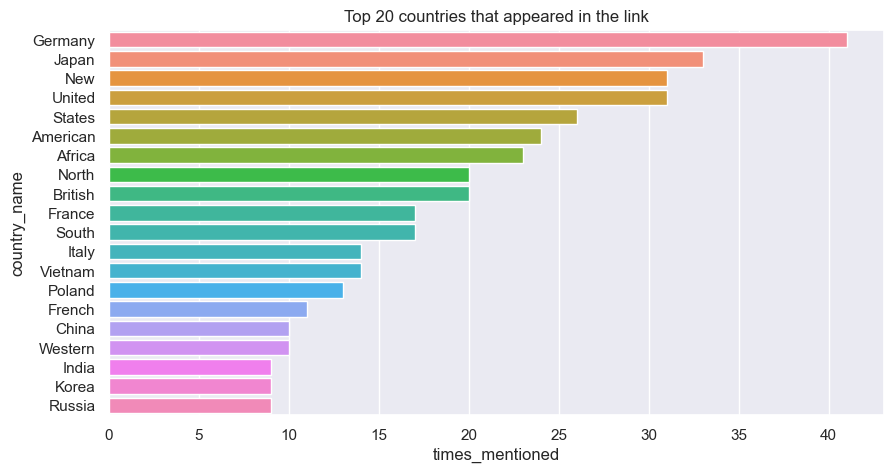

In [328]:
country_df = pd.DataFrame(dict_of_counts.items(), columns = ['country_name','times_mentioned'] )
country_df.head()

,country_name,times_mentioned
0,J,2
1,u,0
2,m,0
3,p,18
4,,0


# Plotting the graph using the scraped data

In [21]:
file_path = "C:\\Users\\Mallika\\workfolder\\20th-century\\countries_list.txt"

In [22]:
#file_path = 'my_list_file.txt'
countries_list = []
with open(file_path, 'r') as file:
    countries_list = [line.strip() for line in file]

countries_df = pd.DataFrame(countries_list, columns=['country_name'])
countries_df.head()

,country_name
0,Afghanistan
1,Albania
2,Algeria
3,Andorra
4,Angola


In [29]:
countries_str = ' '.join([str(elem) for elem in countries_list])

print(countries_str)

Afghanistan Albania Algeria Andorra Angola Antigua Barbuda Argentina Armenia Australia Austria Azerbaijan B[change change source] Bahamas Bahrain Bangladesh Barbados Belarus Belgium Belize Benin Bhutan Bolivia Bosnia Herzegovina Botswana Brazil Brunei Bulgaria Burkina Faso Burundi C[change change source] Cabo Verde Cambodia Cameroon Canada Central African Republic Chad Chile China Colombia Comoros Costa Rica Côte d'Ivoire Croatia Cuba Cyprus Czechia D[change change source] Democratic Republic of the Congo Denmark Djibouti Dominica Dominican Republic E[change change source] Ecuador Egypt El Salvador Equatorial Guinea Eritrea Estonia Eswatini Ethiopia F[change change source] Fiji Finland France G[change change source] Gabon Gambia Georgia Germany Ghana Greece Grenada Guatemala Guinea Guinea-Bissau Guyana H[change change source] Haiti Honduras Hungary I[change change source] Iceland India Indonesia Iran Iraq Ireland Israel Italy J[change change source] Jamaica Japan Jordan K[change change

In [135]:
all_counts = Counter(re.sub(r'\W+', ' ', countries_str).split()) 

In [136]:
dict_of_counts = {d : all_counts[d] for d in countries_list}

In [137]:
country_df = pd.DataFrame(dict_of_counts.items(), columns = ['country_name','times_mentioned'] )
country_df.head()

,country_name,times_mentioned
0,Afghanistan,1
1,Albania,1
2,Algeria,1
3,Andorra,1
4,Angola,1


In [138]:
top20 =country_df.nlargest(20, 'times_mentioned')

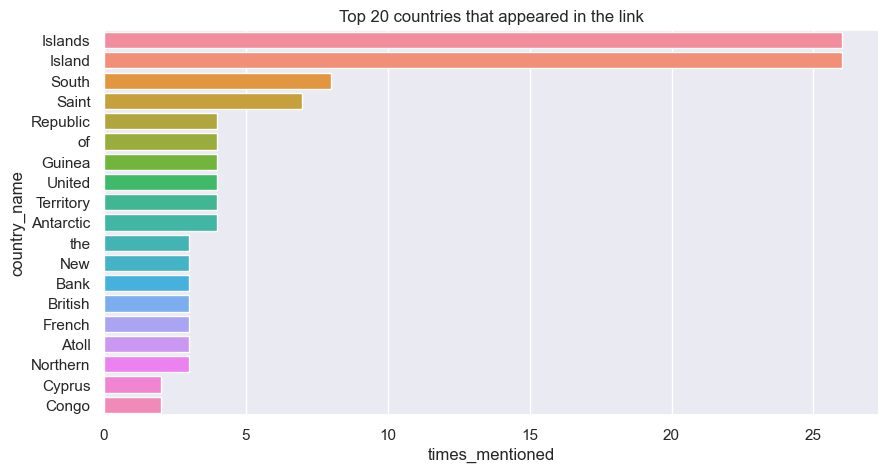

In [140]:
plt.figure(figsize = (10, 5))
with sns.dark_palette("xkcd:blue", 10):
      sns.barplot(x = 'times_mentioned', y = "country_name",
     saturation = 0.9, data = top20[top20.country_name !='change']).set_title("Top 20 countries that appeared in the link")

# Plotting the graph with ready to use file and splitting on space

In [29]:
countries_list = pd.read_csv('countries_list_20th_century_1.5.csv')

In [43]:
#countries_list

In [30]:
cleaned_list = [row.strip() for row in countries_list['country_name']]

In [45]:
#cleaned_list

In [18]:
countries_str_space= ' '.join([str(elem) for elem in cleaned_list])

In [304]:
countries_str_space

"Afghanistan Albania Algeria Andorra Angola Antigua and Barbuda Argentina Armenia Australia Austria Azerbaijan Bahamas, The Bahrain Bangladesh Barbados Belarus Belgium Belize Benin Bhutan Bolivia Bosnia and Herzegovina Botswana Brazil Brunei Bulgaria Burkina Faso Burundi Cambodia Cameroon Canada Cape Verde Central African Republic Chad Chile China, People's Republic of Colombia Comoros Congo, Democratic Republic of the Congo, Republic of the Costa Rica Croatia Cuba Cyprus Czech Republic Denmark Djibouti Dominica Dominican Republic East Timor Ecuador Egypt El Salvador Equatorial Guinea Eritrea Estonia Eswatini Ethiopia Fiji Finland France Gabon Gambia, The Georgia Germany Ghana Greece Grenada Guatemala Guinea Guinea Bissau Guyana Haiti Honduras Hungary Iceland India Indonesia Iran Iraq Ireland Israel Italy Ivory Coast Jamaica Japan Jordan Kazakhstan Kenya Kiribati Korea, North Korea, South Kuwait Kyrgyzstan Laos Latvia Lebanon Lesotho Liberia Libya Liechtenstein Lithuania Luxembourg Mad

In [305]:
all_counts_space = Counter(re.sub(r'\W+', ' ', countries_str_space).split(' ')) 

In [306]:
dict_of_counts_space = {d : all_counts_space[d] for d in cleaned_list}

In [307]:
country_df_space = pd.DataFrame(dict_of_counts_space.items(), columns = ['country_name','times_mentioned'] )
country_df_space.head()

,country_name,times_mentioned
0,Afghanistan,1
1,Albania,1
2,Algeria,1
3,Andorra,1
4,Angola,1


In [308]:
top20_space =country_df_space.nlargest(20, 'times_mentioned')

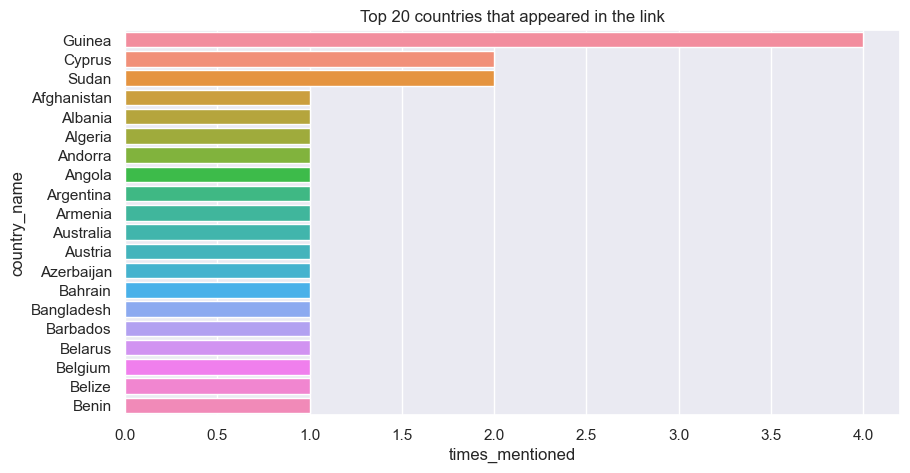

In [309]:
plt.figure(figsize = (10, 5))
with sns.dark_palette("xkcd:blue", 10):
      sns.barplot(x = 'times_mentioned', y = "country_name",
     saturation = 0.9, data = top20_space).set_title("Top 20 countries that appeared in the link")

# Plotting the graph with ready to use file and splitting on comma

In [264]:
countries_str_comma= ','.join([str(elem) for elem in cleaned_list])

In [265]:
countries_str_comma

"Afghanistan,Albania,Algeria,Andorra,Angola,Antigua and Barbuda,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahamas, The,Bahrain,Bangladesh,Barbados,Belarus,Belgium,Belize,Benin,Bhutan,Bolivia,Bosnia and Herzegovina,Botswana,Brazil,Brunei,Bulgaria,Burkina Faso,Burundi,Cambodia,Cameroon,Canada,Cape Verde,Central African Republic,Chad,Chile,China, People's Republic of,Colombia,Comoros,Congo, Democratic Republic of the,Congo, Republic of the,Costa Rica,Croatia,Cuba,Cyprus,Czech Republic,Denmark,Djibouti,Dominica,Dominican Republic,East Timor,Ecuador,Egypt,El Salvador,Equatorial Guinea,Eritrea,Estonia,Eswatini,Ethiopia,Fiji,Finland,France,Gabon,Gambia, The,Georgia,Germany,Ghana,Greece,Grenada,Guatemala,Guinea,Guinea,Bissau,Guyana,Haiti,Honduras,Hungary,Iceland,India,Indonesia,Iran,Iraq,Ireland,Israel,Italy,Ivory Coast,Jamaica,Japan,Jordan,Kazakhstan,Kenya,Kiribati,Korea, North,Korea, South,Kuwait,Kyrgyzstan,Laos,Latvia,Lebanon,Lesotho,Liberia,Libya,Liechtenstein,Lithuania,Luxembourg,Mad

In [272]:
all_counts_comma = Counter(countries_str_comma.split(','))

In [273]:
dict_of_counts_comma = {d : all_counts_comma[d] for d in cleaned_list}

In [274]:
country_df_comma = pd.DataFrame(dict_of_counts_comma.items(), columns = ['country_name','times_mentioned'] )
country_df_comma.head()

,country_name,times_mentioned
0,Afghanistan,1
1,Albania,1
2,Algeria,1
3,Andorra,1
4,Angola,1


In [276]:
top20_comma =country_df_comma.nlargest(20, 'times_mentioned')

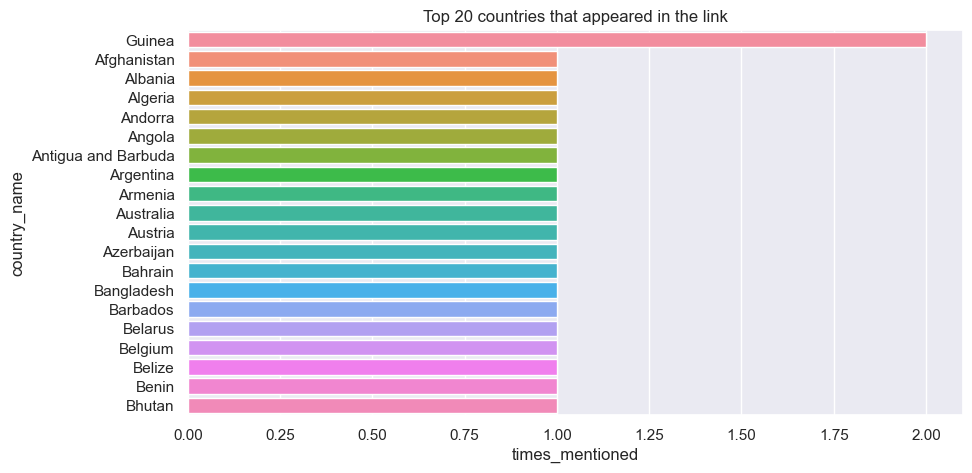

In [277]:
plt.figure(figsize = (10, 5))
with sns.dark_palette("xkcd:blue", 10):
      sns.barplot(x = 'times_mentioned', y = "country_name",
     saturation = 0.9, data = top20_comma).set_title("Top 20 countries that appeared in the link")

# Plotting the graph with ready to use file and filtered web scraped data

In [46]:
listToStr = ' '.join([str(elem) for elem in filtered_words])

In [48]:
#listToStr

In [49]:
all_counts = Counter(re.sub(r'\W+', ' ', listToStr).split()) 

In [51]:
#all_counts

In [33]:
dict_of_counts = {d :all_counts[d] for d in cleaned_list}

In [34]:
country_df = pd.DataFrame(dict_of_counts.items(), columns = ['country_name','times_mentioned'] )
country_df.head()

,country_name,times_mentioned
0,Afghanistan,1
1,Albania,2
2,Algeria,1
3,Andorra,0
4,Angola,1


In [52]:
# pd.options.display.max_rows = None
# country_df.sort_values(by = 'times_mentioned', ascending = False)

In [35]:
top20 =country_df.nlargest(20, 'times_mentioned')

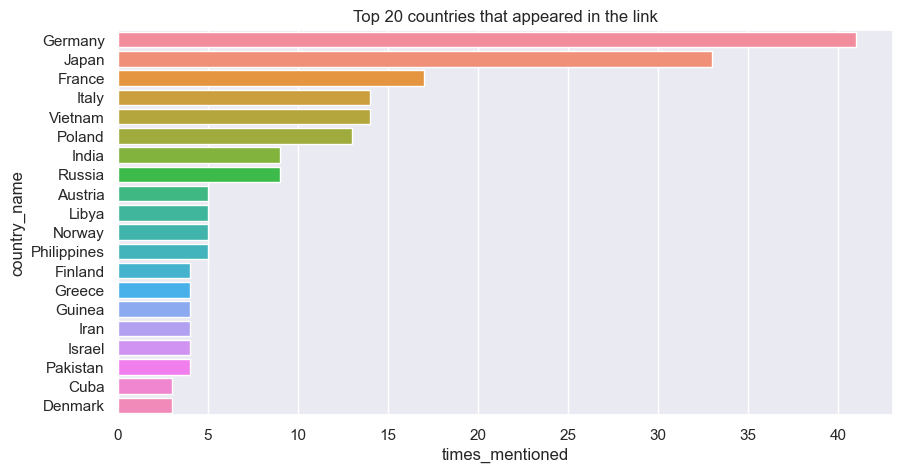

In [36]:
plt.figure(figsize = (10, 5))
with sns.dark_palette("xkcd:blue", 10):
      sns.barplot(x = 'times_mentioned', y = "country_name",
     saturation = 0.9, data = top20[top20.country_name !='change']).set_title("Top 20 countries that appeared in the link")

<!-- The one noticeable point is that the country names that consist more than 1 word are split by each word and consequently each word is considered a separate country while calculating the frquency of appearance of each country in the scraped data. So the graph is kind of misleading and should be corrceted for this gap. -->

## After plotting the graph with the ready to use file and filtered web scraped data, Germany, Japan and France appears at top of the list in terms of appearance.